# Trabajo Practico Final
Integrantes:
* Agustin Fernandez Berge
* Ramiro Gatto 

Primero importamos todas las libreraias que vamos a ir usando durante el proyecto

In [31]:
import os
import time
import keras
import numpy as np
import matplotlib.pyplot as plt

from datetime import timedelta
from keras.callbacks import Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight


Definimos funciones para mostrar las gráficas utilizadas durante el proyecto

In [32]:
def curvasEntrenamiento(history, history_fine_tune=None, test_values=None):
    plt.figure(figsize=(12, 5))
    train_color = '#1f77b4'
    validation_color = '#ff7f0e'
    train_finetunning_color = '#0d3d6b'
    validation_finetunning_color = '#b36b00'
    test_color = '#e74c3c'
    test_after_finetunning_color = '#27ae60'

    extra_ticks = []

    # Accuracy
    plt.subplot(1, 2, 1)
    # Grafico las curvas de entrenamiento y validación iniciales
    plt.plot(history.history['accuracy'], label='Entrenamiento (Inicial)', color=train_color, linestyle='-')
    plt.plot(history.history['val_accuracy'], label='Validación (Inicial)', color=validation_color, linestyle='--')
    
    # Grafico el mejor valor de val accuracy
    best_val_acc_epoch = np.argmax(history.history['val_accuracy'])
    
    # Marcar el mejor valor de val accuracy
    extra_ticks.append(history.history['val_accuracy'][best_val_acc_epoch])

    plt.scatter(best_val_acc_epoch, history.history['val_accuracy'][best_val_acc_epoch], color=validation_color, marker='o', s=60, label='Mejor val (Inicial)')
    
    # Si hubo fine tunning, hago lo mismo para las curvas de fine tunning
    if history_fine_tune is not None:
        # Traslado las epocas hacia atras para conectar las graficas
        epochs_finetune = range(len(history.history['accuracy'])-1, len(history.history['accuracy']) + len(history_fine_tune.history['accuracy'])-1)
        plt.plot(epochs_finetune, history_fine_tune.history['accuracy'], label='Entrenamiento (Fine-tuning)', color=train_finetunning_color, linestyle='-')
        plt.plot(epochs_finetune, history_fine_tune.history['val_accuracy'], label='Validación (Fine-tuning)', color=validation_finetunning_color, linestyle='--')
        
        # No contamos el ultimo valor para el best_val porque viene del entrenamiento inicial
        # y no del fine-tuning
        best_val_acc_ft_epoch = np.argmax(history_fine_tune.history['val_accuracy'][1:]) + 1
        best_val_acc_ft_actual_epoch = best_val_acc_ft_epoch + len(history.history['accuracy']) - 1 # nuevamente tiro el valor un poco para atrasz
        # Marcar el mejor valor de val accuracy del fine-tuning
        extra_ticks.append(history_fine_tune.history['val_accuracy'][best_val_acc_ft_epoch])

        plt.scatter(best_val_acc_ft_actual_epoch, history_fine_tune.history['val_accuracy'][best_val_acc_ft_epoch], color=validation_finetunning_color, marker='o', s=60, label='Mejor val (Fine-tuning)')
        # Esta linea marca la epoca de inicio del fine-tuning
        plt.axvline(x=len(history.history['accuracy'])-1, color='darkviolet', linestyle=':', label='Inicio Fine-tuning')
    
    # Graficar tambien los valores de test
    if test_values is not None:
        extra_ticks.append(test_values['accuracy'])
        plt.axhline(y=test_values['accuracy'], linestyle='-.', label='Test', color=test_color)
        if history_fine_tune is not None:
            extra_ticks.append(test_values['finetunning accuracy'])
            plt.axhline(y=test_values['finetunning accuracy'], color=test_after_finetunning_color, linestyle='-.', label='Test (Fine-tuning)')
    plt.title('Precisión (accuracy)')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    
    def plotExtraTicks():
        # Agregar los extra ticks al eje y
        if extra_ticks:
            current_y_ticks = plt.yticks()[0]
            new_y_ticks = np.concatenate((current_y_ticks, extra_ticks))
            new_y_ticks = np.unique(new_y_ticks)  # Eliminar duplicados
            # Eliminar valores demasiado cercanos entre sí
            new_y_ticks = np.sort(new_y_ticks[np.abs(np.diff(new_y_ticks, prepend=np.nan)) > 0.03])

            plt.yticks(new_y_ticks)
    plotExtraTicks()

    plt.grid(True, linestyle=':', alpha=0.5)

    # Para el loss hago lo mismo
    extra_ticks = []
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento (Inicial)', color=train_color, linestyle='-')
    plt.plot(history.history['val_loss'], label='Validación (Inicial)', color=validation_color, linestyle='--')
    best_val_loss_epoch = np.argmin(history.history['val_loss'])
    extra_ticks.append(history.history['val_loss'][best_val_loss_epoch])
    plt.scatter(best_val_loss_epoch, history.history['val_loss'][best_val_loss_epoch], color=validation_color, marker='o', s=60, label='Mejor val (Inicial)')
    if history_fine_tune is not None:
        plt.plot(epochs_finetune, history_fine_tune.history['loss'], label='Entrenamiento (Fine-tuning)', color=train_finetunning_color, linestyle='-')
        plt.plot(epochs_finetune, history_fine_tune.history['val_loss'], label='Validación (Fine-tuning)', color=validation_finetunning_color, linestyle='--')
        
        best_val_loss_ft_epoch = np.argmin(history_fine_tune.history['val_loss'][1:]) + 1  # No contamos el primer valor porque es el del entrenamiento inicial
        best_val_loss_ft_actual_epoch = best_val_loss_ft_epoch + len(history.history['loss']) - 1 # Tiro el punto hacia atras
        extra_ticks.append(history_fine_tune.history['val_loss'][best_val_loss_ft_epoch])
        plt.scatter(best_val_loss_ft_actual_epoch, history_fine_tune.history['val_loss'][best_val_loss_ft_epoch], color=validation_finetunning_color, marker='o', s=60, label='Mejor val (Fine-tuning)')
        plt.axvline(x=len(history.history['loss'])-1, color='darkviolet', linestyle=':', label='Inicio Fine-tuning')
    if test_values is not None:
        extra_ticks.append(test_values['loss'])
        plt.axhline(y=test_values['loss'], linestyle='-.', label='Test', color=test_color)
        if history_fine_tune is not None:
            extra_ticks.append(test_values['finetunning loss'])
            plt.axhline(y=test_values['finetunning loss'], color=test_after_finetunning_color, linestyle='-.', label='Test (Fine-tuning)')
    plt.title('Pérdida (loss)')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.grid(True, linestyle=':', alpha=0.5)


    # No agregamos ticks extras en la grafica de loss porque los valores son
    # demasiado pequeños
    #plotExtraTicks()

    # Añado la leyenda
    handles, labels_ = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels_, handles))
    plt.figlegend(by_label.values(), by_label.keys(), ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.15))
    plt.tight_layout()
    plt.show()

def clasificarTest(model, test):
    # Obtener nombres de clases y número de clases
    class_indices = test.class_indices
    class_names = list(class_indices.keys())
    num_classes = len(class_names)
    
    # Obtener todas las imágenes y etiquetas verdaderas del test set
    test.reset()
    y_true = []
    y_pred = []
    for i in range(len(test)):
        x_batch, y_batch = test[i]
        preds = model.predict(x_batch, verbose=0)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Crear figura con subplots en una grilla de 4 columnas
    fig, axs = plt.subplots((len(class_names) + 3) // 4, 4, figsize=(20, 12), constrained_layout=True)
    axs = axs.flatten()
    for idx, class_name in enumerate(class_names):
        mask = y_true == idx
        pred_for_class = y_pred[mask]
        ax = axs[idx]
        counts, bins, patches = ax.hist(
            pred_for_class, 
            bins=np.arange(num_classes+1)-0.5, 
            rwidth=0.85, 
            align='mid', 
            edgecolor='black'
        )
        for bar_idx, patch in enumerate(patches):
            if bar_idx == idx:
                patch.set_facecolor('#e74c3c')  # rojo para la clase real
            else:
                patch.set_facecolor('#3498db')  # azul sino
        ax.set_xticks(range(num_classes))
        ax.set_xticklabels(class_names, rotation=45, fontsize=10)
        
        # Fijar el mismo limite de altura para todos los graficos
        ax.set_ylim(0, 11)
        ax.set_title(f'Clase real: {class_name}', fontsize=13)  # Sin negrita
        ax.set_xlabel('Clase predicha', fontsize=11)
        ax.set_ylabel('Cantidad', fontsize=11)
        ax.grid(axis='y', linestyle=':', alpha=0.5)
        # Mostrar porcentaje de aciertos sobre la barra correcta, pero solo si entra en el gráfico
        correct = np.sum(pred_for_class == idx)
        total = len(pred_for_class)
        if total > 0:
            percent = 100 * correct / total
            # Solo mostrar si el texto entra dentro del eje y
            y_max = ax.get_ylim()[1]
            y_pos = counts[idx] + 0.15
            if y_pos < y_max * 0.95:
                ax.text(
                    idx, y_pos, 
                    f'{percent:.1f}%', 
                    ha='center', va='bottom', 
                    fontsize=11, color='#e74c3c', fontweight='bold'
                )
    
    # Elimina espacio vacios del subplots
    for j in range(num_classes, len(axs)):
        fig.delaxes(axs[j])
    fig.suptitle('Distribución de clases predichas para cada clase real (Test)', fontsize=16, y=1.02)  # Sin negrita
    plt.show()


Callback para detener el train después de un cierto tiempo

In [33]:
class TimedStopping(Callback):
    """
    Stop training when a specified amount of time has passed.

    # Arguments
        minutes: The maximum time in minutes before stopping training.
        verbose: Verbosity mode (0 or 1). If 1, a message is printed when stopping.
    """
    def __init__(self, minutes=None, verbose=0):
        super(Callback, self).__init__()
        self.start_time = 0
        self.seconds = minutes * 60 if minutes is not None else None
        self.verbose = verbose

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if time.time() - self.start_time > self.seconds:
            self.model.stop_training = True
            if self.verbose:
                print(f'\nTimedStopping: Stopping after {self.seconds/60} minutes.')

timed_stopping_cb = TimedStopping(minutes=1, verbose=1)

Como primer paso cargamos los ejemplos del dataset, aplicamos data aumentation a los dato del train y dividimos los mismos para formar el conjunto de validación. 

In [34]:

# Ruta al dataset
pathDataset = "./dataset"

IMAGE_SIZE = 300
BATCH_SIZE = 32

# Obtengo los datos, a los datos de entrenamiento se le aplica data aumentation
# Estas son las clases del dataset que se van a usar
used_classes = ['bird', 'monkey', 'boar', 'tiger', 'rat', 'ram', 'dog', 'horse', 'hare', 'ox', 'dragon', 'snake']
numClasses = len(used_classes)
pathDataset = "./dataset"

trainValDataMod = ImageDataGenerator(
    validation_split=0.10,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

testDataMod = ImageDataGenerator()

# Datos de entrenamiento
train = trainValDataMod.flow_from_directory(
    directory=pathDataset + "/train",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    classes=used_classes,
    class_mode="categorical",
    subset="training"
)

# Datos de validación
validation = trainValDataMod.flow_from_directory(
    directory=pathDataset + "/train",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    classes=used_classes,
    class_mode="categorical",
    subset="validation"
)

# Datos de prueba
test = testDataMod.flow_from_directory(
    directory=pathDataset + "/test",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    classes=used_classes,
    class_mode="categorical",
    batch_size=1,
)

Found 1771 images belonging to 12 classes.
Found 189 images belonging to 12 classes.
Found 81 images belonging to 12 classes.


Creamos el modelo (congelamos las capas del mismo)

In [35]:
base_model = keras.applications.InceptionV3(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freezamos el modelo (la base)
base_model.trainable = False

# Creamos nuevo modelo en top
inputs = keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Escalamos imagenes para que esten entre -1 y 1
scale_layer = keras.layers.Rescaling(scale=1/ 127.5,  offset=-1)

model = keras.Sequential([
    inputs,
    scale_layer,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(numClasses, activation='softmax', name="output-layer") # esta capa clasifica las clases
], name="Clasificador_sellos_Naruto")

model.summary(show_trainable=True)

Model: "Clasificador_sellos_Naruto"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ rescaling_2 (Rescaling)     │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ inception_v3 (Functional)   │ (None, 8, 8, 2048)    │ 21,802,784 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_2  │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ output-layer (Dense)        │ (None, 12)            │     24,588 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 21,827,372 (83.26 MB)

 Trainable params: 24,588 (96.05 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

Entrenamos el modelo creado


In [ ]:
epochs = 100 # Ponemos un numero alto para que el entrenamiento se corte 
             # con el TimedStopping

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train.classes),
    y=train.classes
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalFocalCrossentropy(alpha=class_weights), # Usamos balanceo de clases
    metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')]  # Usamos categorical_accuracy en vez de accuracy
)

# Creamos las callback
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=15,
    monitor='val_accuracy',
    mode='max',
    restore_best_weights=True
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.1,
    patience=5,
    monitor='val_accuracy',
    mode='max',
    min_lr=1e-7
)

# Entrenamos el modelo
history = model.fit(
    train,
    validation_data=validation,
    epochs=epochs,
    callbacks=[early_stopping_cb, reduce_lr_cb, timed_stopping_cb]
)

# Evaluamos sobre el conjunto de test
test_loss, test_accuracy = model.evaluate(test)
test_values = {
    'loss': test_loss,
    'accuracy': test_accuracy
}


/home/don-berge/Documentos/IIA-TPS/TP-FINAL/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3502 - loss: 1.6992

/home/don-berge/Documentos/IIA-TPS/TP-FINAL/.venv/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_categorical_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):



TimedStopping: Stopping after 1.0 minutes.
56/56 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.3540 - loss: 1.6892 - val_accuracy: 0.7037 - val_loss: 0.5851 - learning_rate: 0.0010


/home/don-berge/Documentos/IIA-TPS/TP-FINAL/.venv/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_categorical_accuracy` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/home/don-berge/Documentos/IIA-TPS/TP-FINAL/.venv/lib/python3.12/site-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_categorical_accuracy` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.3778 - loss: 1.2904


Curvas entrenamientos (Sin fine tunning)


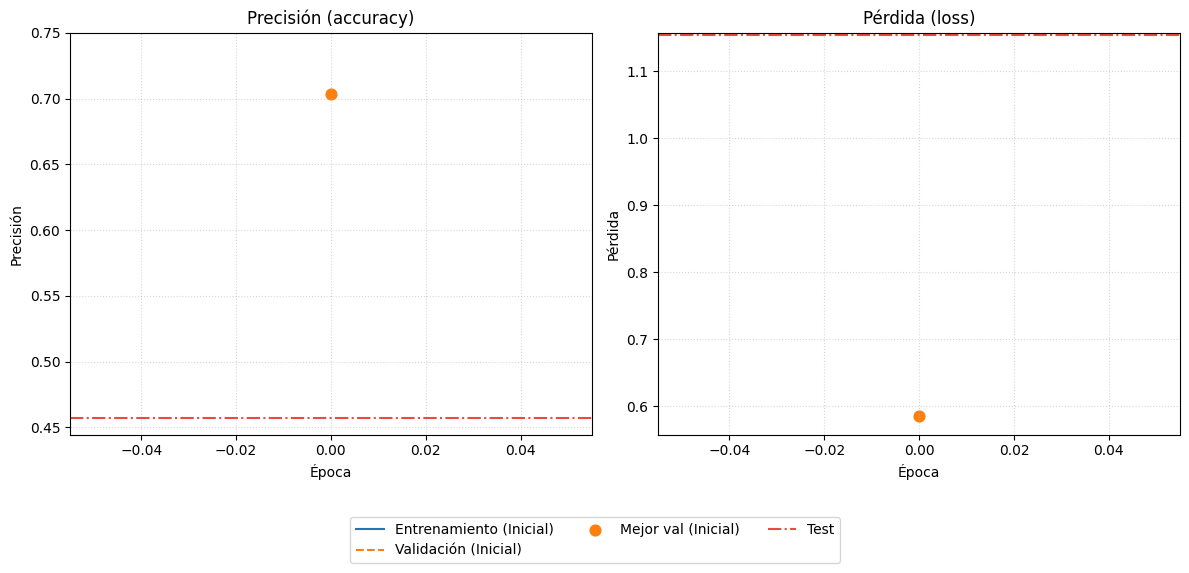

In [37]:

print("Curvas entrenamientos (Sin fine tunning)")
curvasEntrenamiento(history, test_values=test_values)

Ahorra realizamos en fine-tunning (descongelamos las ultimas 100 capas)

In [ ]:
base_model_layers = len(base_model.layers)

print(f"El Base model tiene {base_model_layers} capas.")

# Fine-tunning en las ultimas 100 capas
finetunning_layers = 100
fine_tune_at = base_model_layers - finetunning_layers  
print("Capas no entrenables:", fine_tune_at)
print("Capas entrenables:", base_model_layers - fine_tune_at)

# Descongelamos las capas que vamos a entrenar
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Recompilamos el modelo con un learning rate más bajo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalFocalCrossentropy(alpha=class_weights),
    metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')]  # Usamos categorical_accuracy en vez de accuracy
)

fineTunning_epochs = 100 # Ponemos un numero alto para que el entrenamiento se
                         # corte con el TimedStopping
total_epochs = len(history.epoch) + fineTunning_epochs

# Entrenamos el modelo de nuevo
history_fine_tune = model.fit(
    train,
    validation_data=validation,
    epochs=total_epochs,
    callbacks=[early_stopping_cb, reduce_lr_cb, timed_stopping_cb],
    initial_epoch=len(history.epoch)
)

# Insertar el ultimo valor de las curvas de entrenamiento iniciales al inicio
# de las curvas de fine-tunning para conectar las graficas
history_fine_tune.history['accuracy'].insert(0, history.history['accuracy'][-1])
history_fine_tune.history['val_accuracy'].insert(0, history.history['val_accuracy'][-1])
history_fine_tune.history['loss'].insert(0, history.history['loss'][-1])
history_fine_tune.history['val_loss'].insert(0, history.history['val_loss'][-1])


# Evaluamos sobre el conjunto de test
test_loss, test_accuracy = model.evaluate(test)
test_values['finetunning loss'] = test_loss
test_values['finetunning accuracy'] = test_accuracy

El Base model tiene 311 capas.
Capas no entrenables: 211
Capas entrenables: 100
Epoch 2/101
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9627 - loss: 0.0674
TimedStopping: Stopping after 1.0 minutes.
56/56 ━━━━━━━━━━━━━━━━━━━━ 209s 3s/step - accuracy: 0.9629 - loss: 0.0671 - val_accuracy: 0.8836 - val_loss: 0.1914 - learning_rate: 1.0000e-04
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.6518 - loss: 0.7578


Curvas entrenamientos (Luego del fine tunning)


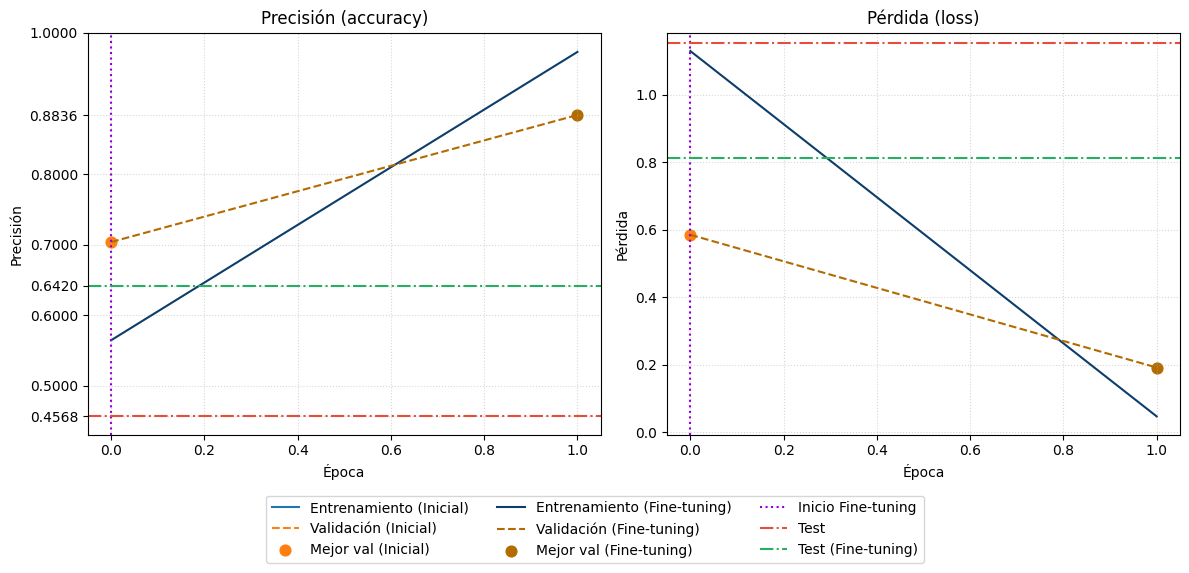

In [40]:
print("Curvas entrenamientos (Luego del fine tunning)")

curvasEntrenamiento(history, history_fine_tune, test_values=test_values)


Veamos como clasifica las imágenes del test

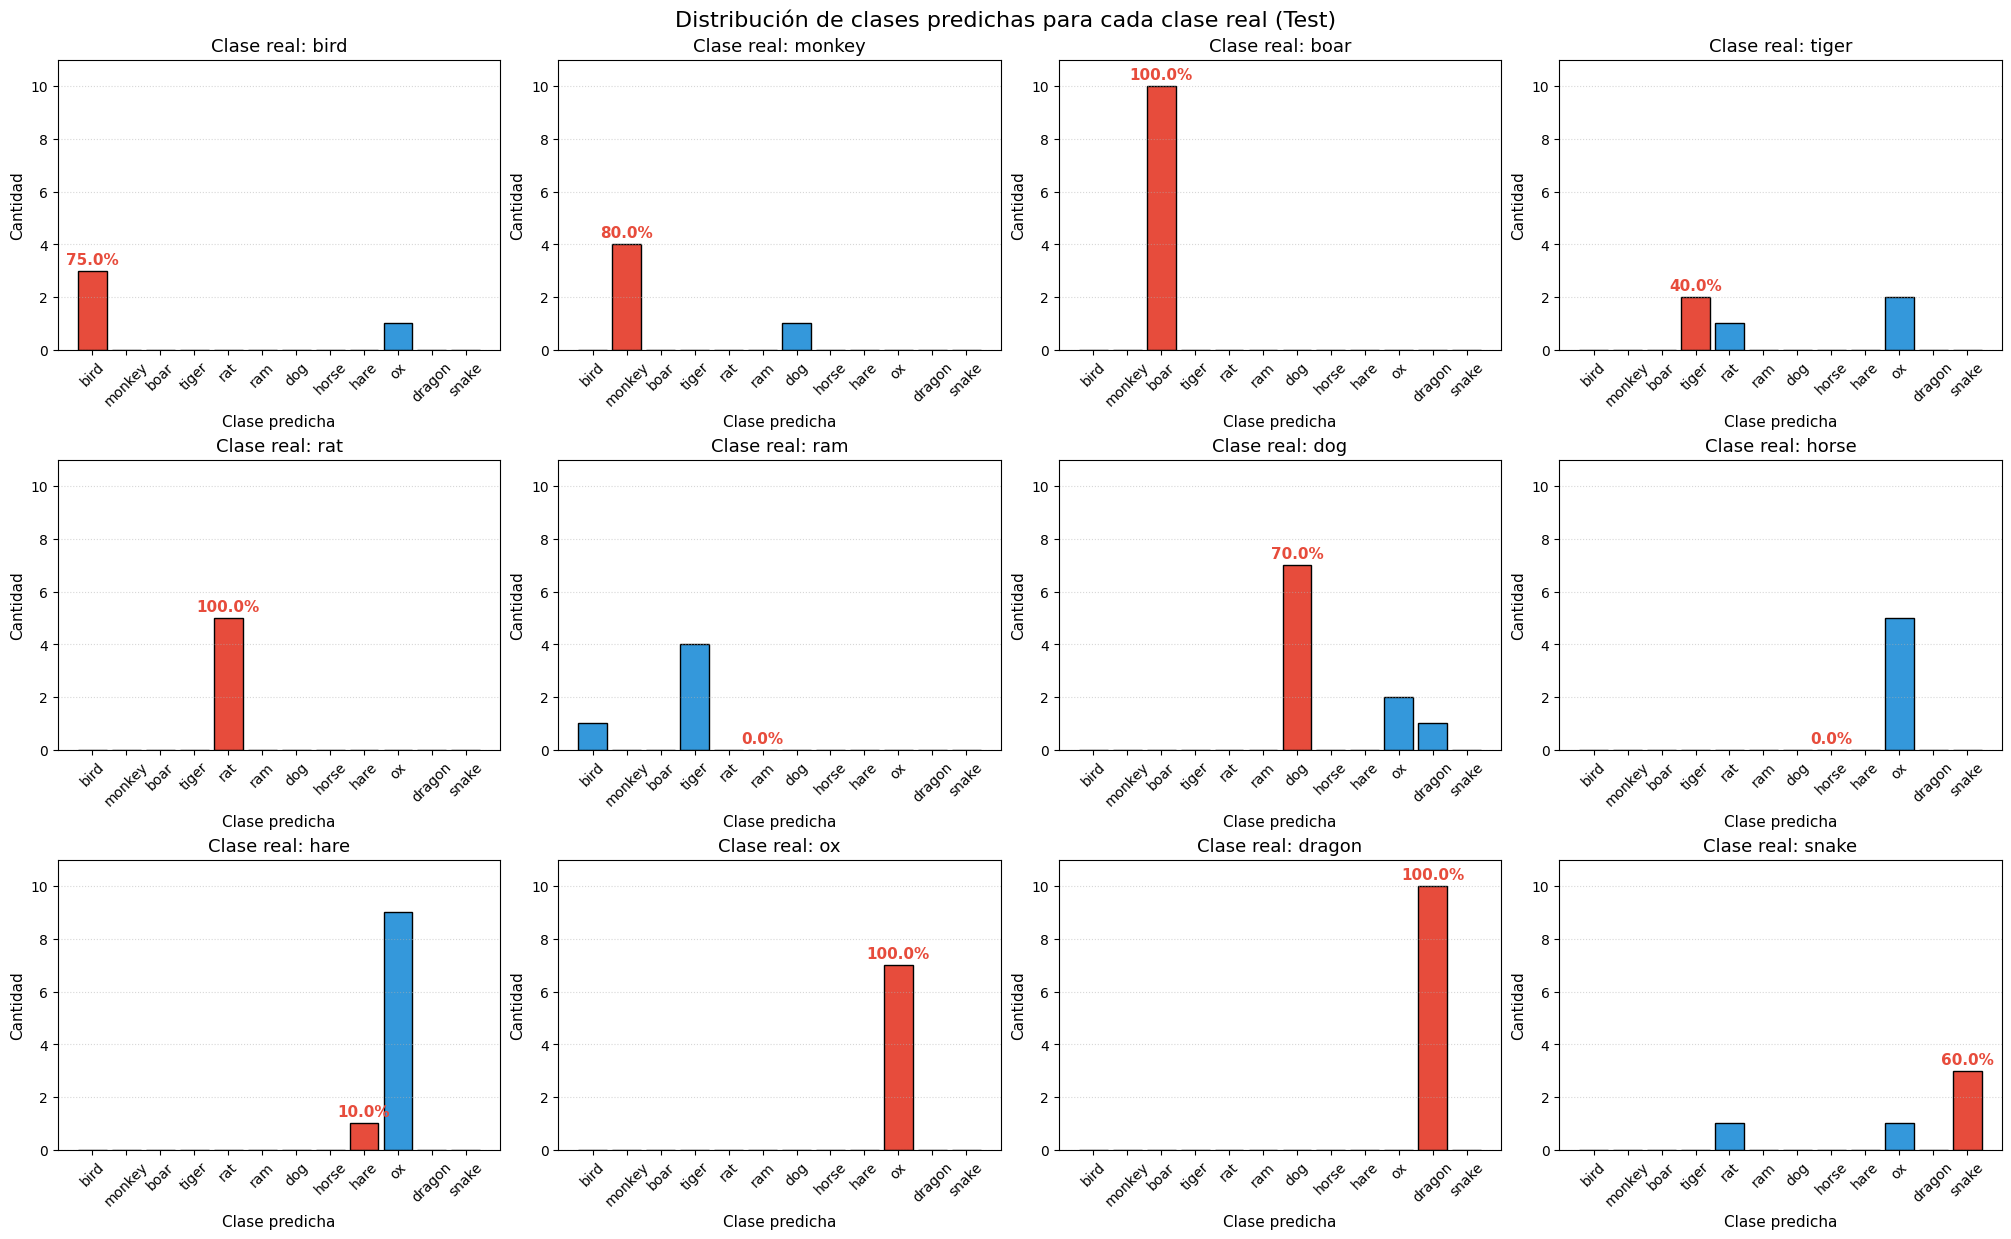

In [41]:
clasificarTest(model, test)

Finalmente guardamos el modelo en un archivo .keras para poder cargarlo luego

In [ ]:
model.save('clasificador_naruto.keras')